In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/IBM Teleco Churn Dataset.csv")

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [3]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [4]:
cat_cols = X.select_dtypes(include=["object"]).columns
cat_cols

/var/folders/zb/cmj7dmkn431g2wdr2y_lnrww0000gn/T/ipykernel_2885/3486594142.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

One-Hot Encoding

In [5]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X.shape

(7043, 30)

Train/Test split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train baseline model

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



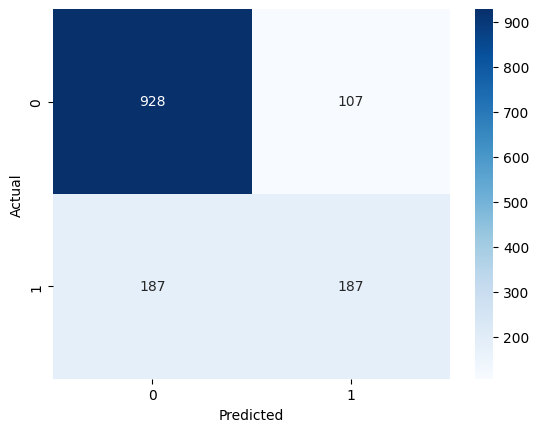

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature importance

In [10]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

TotalCharges                      0.193201
tenure                            0.171705
MonthlyCharges                    0.168201
InternetService_Fiber optic       0.039103
PaymentMethod_Electronic check    0.038334
Contract_Two year                 0.031360
gender_Male                       0.028517
OnlineSecurity_Yes                0.027556
PaperlessBilling_Yes              0.025673
Partner_Yes                       0.023302
dtype: float64

Save the trained model

In [11]:
import joblib

joblib.dump(model, "../src/models/churn_model.pkl")
joblib.dump(X.columns.tolist(), "../src/models/model_columns.pkl")

['../src/models/model_columns.pkl']